In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [20]:
train_dir = "data/food-101-tiny/train"
valid_dir = "data/food-101-tiny/valid"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 1500 files belonging to 10 classes.
Found 500 files belonging to 10 classes.
['apple_pie', 'bibimbap', 'cannoli', 'edamame', 'falafel', 'french_toast', 'ice_cream', 'ramen', 'sushi', 'tiramisu']


In [22]:
class_names = train_ds.class_names

print(class_names)

['apple_pie', 'bibimbap', 'cannoli', 'edamame', 'falafel', 'french_toast', 'ice_cream', 'ramen', 'sushi', 'tiramisu']


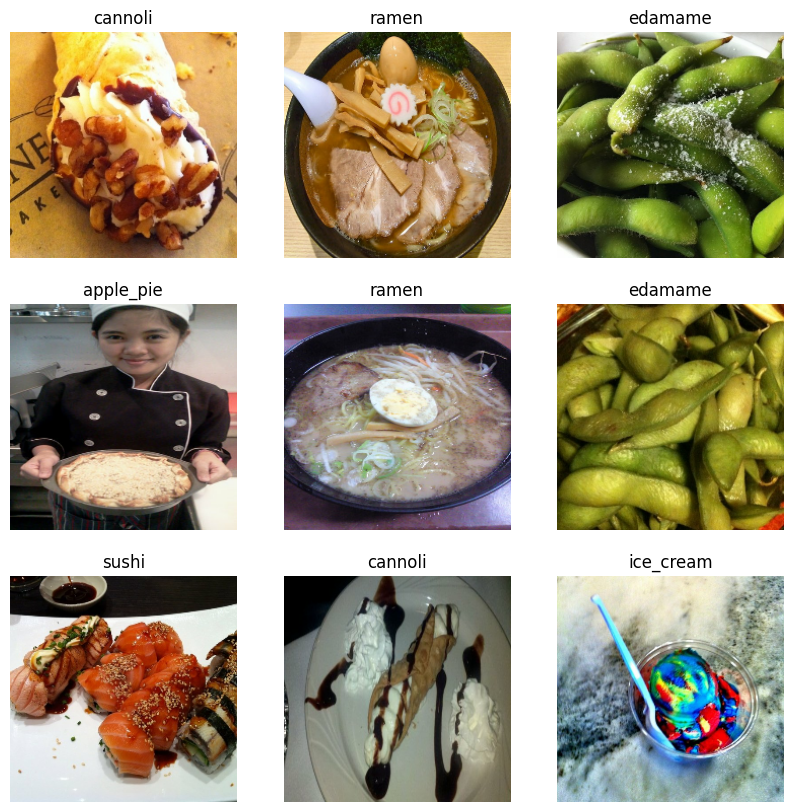

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

Data Normalization 

In [24]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

valid_ds = valid_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

Build CNN Model 

In [25]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )

])

model.summary()

c:\Gayatri\Prodigy\PRODIGY_ML_05\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Food Prediction Function

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
print(tf.__version__)

2.21.0


In [ ]:
print(class_names)

['apple_pie', 'bibimbap', 'cannoli', 'edamame', 'falafel', 'french_toast', 'ice_cream', 'ramen', 'sushi', 'tiramisu']


In [ ]:
import tensorflow as tf

In [ ]:
class_names = train_ds.class_names

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names),activation='softmax')
])

c:\Gayatri\Prodigy\PRODIGY_ML_05\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
print(model)

<Sequential name=sequential, built=True>


In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 575ms/step - accuracy: 0.1593 - loss: 2.2991 - val_accuracy: 0.2600 - val_loss: 2.0272
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 549ms/step - accuracy: 0.2440 - loss: 2.0534 - val_accuracy: 0.3160 - val_loss: 1.9329
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 554ms/step - accuracy: 0.2787 - loss: 1.9638 - val_accuracy: 0.3520 - val_loss: 1.8352
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 546ms/step - accuracy: 0.3447 - loss: 1.8222 - val_accuracy: 0.3120 - val_loss: 1.8656
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 554ms/step - accuracy: 0.4067 - loss: 1.6564 - val_accuracy: 0.3680 - val_loss: 1.7910
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 549ms/step - accuracy: 0.5080 - loss: 1.4054 - val_accuracy: 0.3140 - val_loss: 1.9593
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 555ms/step - accuracy: 0.5860 - loss: 1.2028 - val_accuracy: 0.3440 - val_loss: 1.9391
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 554ms/step - accuracy: 0.6707 - loss: 0.9460 - val_accu

In [30]:
model.save("food_model.keras")

Model Accuracy

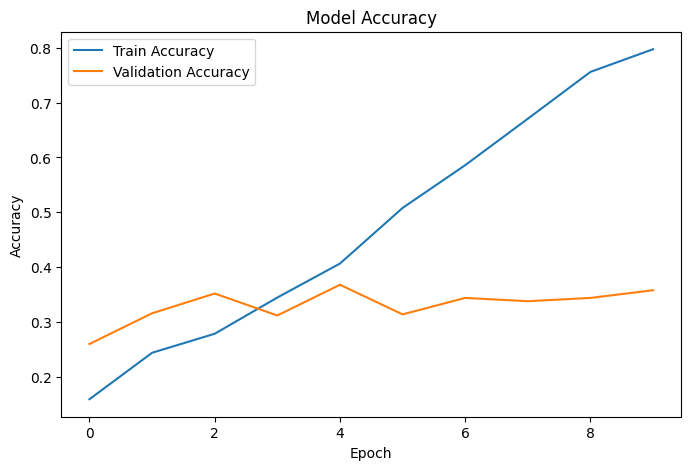

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.savefig("screenshots/accuracy_graph.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

Plot Loss Graph

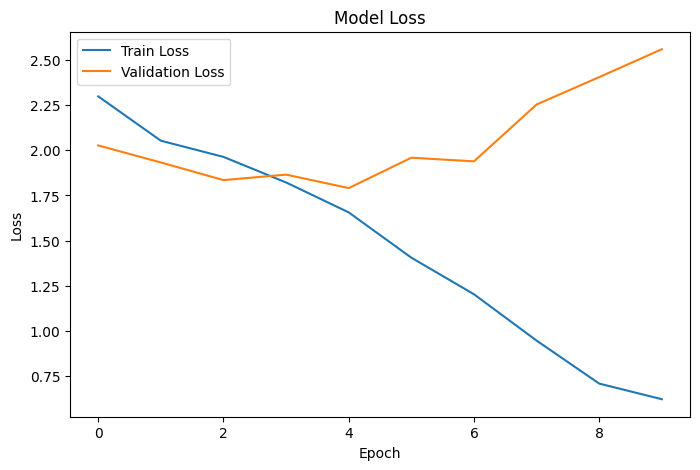

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.savefig("screenshots/loss_graph.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

In [33]:
print(model)

<Sequential name=sequential_1, built=True>


In [34]:
import os
print(os.listdir())

['data', 'food_model.keras', 'PRODIGY_ML_05.ipynb', 'venv']


Final Food Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Predicted Food: ice_cream


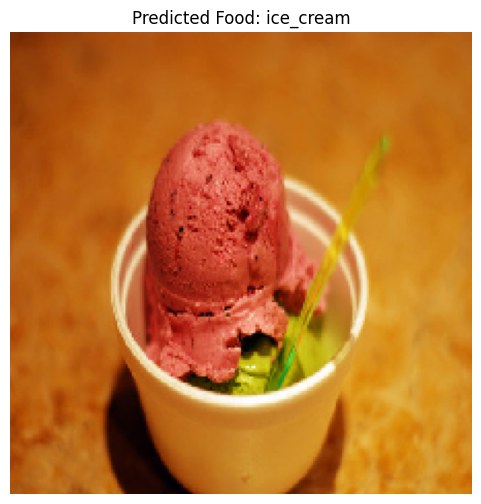

In [43]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\gayat\pictures\1164.jpg"

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Food:", predicted_class)

plt.figure(figsize=(6,6))

plt.imshow(img)
plt.title(f"Predicted Food: {predicted_class}")
plt.axis("off")

plt.savefig("screenshots/prediction.png",
            bbox_inches='tight',
            dpi=300)

plt.show()

Calorie Prediction

In [47]:
calorie_dict = {
    "apple_pie": 296,
    "bibimbap": 490,
    "cannoli": 216,
    "edamame": 120,
    "falafel": 333,
    "french_toast": 356,
    "ice_cream": 207,
    "ramen": 436,
    "sushi": 200,
    "tiramisu": 283
}

food = predicted_class
calories = calorie_dict.get(food, "Unknown")

print("Food:", food)
print("Estimated Calories:", calories, "kcal")

Food: ice_cream
Estimated Calories: 207 kcal


In [37]:
import tensorflow as tf

model = tf.keras.models.load_model("food_model.keras")

In [39]:
import os

os.makedirs("screenshots", exist_ok=True)